In [253]:
import numpy as np
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import skimage
import sys
import os
import networkx as nx

from matplotlib.ticker import MaxNLocator
import matplotlib as mpl
import matplotlib.tri as mtri
import cmath
import matplotlib.colors as colors
from skimage import measure
from numpy.linalg import inv
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

from numpy import ones,vstack
from numpy.linalg import lstsq

from wing import *

In [108]:
# population_130+FMNH_4598426_hw_mapped_cell_circularity
name="population_130+FMNH_4598426"

circ=np.loadtxt("./wing_stats/"+name+"_hw_mapped_cell_circularity.txt")
area=np.loadtxt("./wing_stats/"+name+"_hw_mapped_cell_frac_area.txt")

In [118]:
circ[0,0]

-1.0

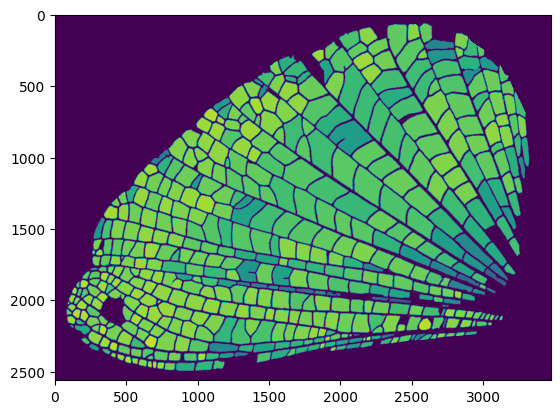

In [3]:
plt.imshow(circ,vmin=0,vmax=1)

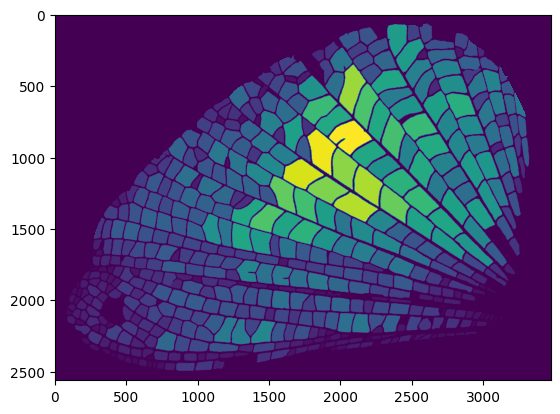

In [4]:
plt.imshow(area,vmin=0,vmax=0.006)

In [10]:
np.max(area)

0.005978366951548661

In [255]:
ref_name="population_60+FMNH_4602368_hw" # index 10
gray=np.load("./outline/"+ref_name+"_outline.npy")

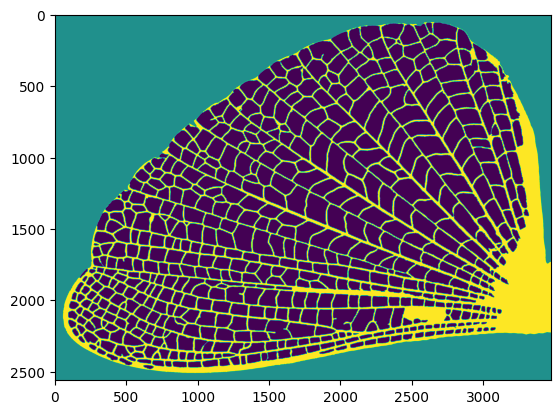

In [7]:
plt.imshow(gray)

In [256]:
img_idx=10
a=Wing("./sample_data",img_idx)

In [13]:
a.img_x

array([ 261.91180033,  508.11312871,  776.12976467,  975.58400538,
       1193.73708116, 1402.54073941, 1683.02326541, 1926.10812128,
       2268.9200975 , 2499.53906333, 2804.95336942, 2920.26285233,
       3088.55236794, 3259.95835605, 3228.79363094, 3213.21126838,
       3206.97832336, 3259.95835605, 3337.87016883, 3384.6172565 ,
       1873.12808859, 2035.18465917, 2222.17300984, 2527.58731593,
       2786.25453436, 3060.50411534, 3238.14304847,   99.72570015,
       2162.96003213, 3291.12308116])

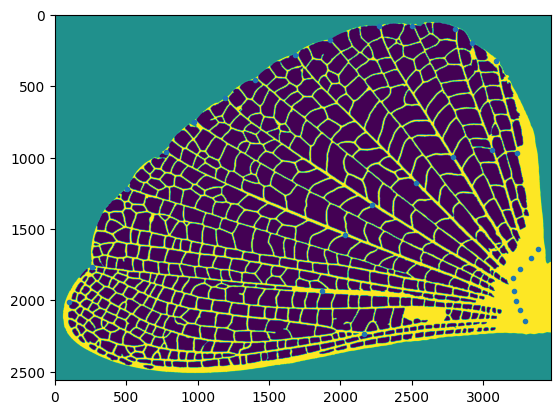

In [257]:
plt.imshow(a.gray)
plt.plot(a.img_x,a.img_y,'.')

In [30]:
pt=np.load("./sample_data/"+ref_name+"_pt.npy")
bdy=np.load("./sample_data/"+ref_name+"_bdy.npy")

In [62]:
for i in range(7):
    for j in range(12):
        x=int(pt[i,j,1])
        y=int(pt[i,j,0])
        a.gray[x-20:x+20,y-20:y+20]=0.2

In [47]:
pt[:,:,0]

array([[3259.95835605, 2987.31981652, 2714.68127698, 2442.04273745,
        2169.40419792, 1896.76565838, 1624.25323933, 1351.78495153,
        1079.31666373,  806.84837593,  534.38008813,  261.91180033],
       [3228.79363094, 3004.64289415, 2780.49215736, 2556.34142056,
        2332.19068377, 2108.03994698, 1878.87943455, 1650.65976777,
        1422.70106568, 1196.6463022 ,  973.73548798,  760.        ],
       [3213.21126838, 3028.4465843 , 2843.68190022, 2658.91721614,
        2474.15253206, 2289.38784797, 2105.52117006, 1911.56577824,
        1729.73170107, 1536.62946291, 1357.20080901, 1185.        ],
       [3206.97832336, 3068.16349949, 2929.34867563, 2790.53385176,
        2651.7190279 , 2506.86781271, 2362.07085168, 2219.30415133,
        2075.15804496, 1932.64700103, 1797.3124207 , 1672.        ],
       [3259.95835605, 3168.51742752, 3077.07649899, 2985.63557046,
        2894.19464193, 2802.7537134 , 2702.94279546, 2607.35100216,
        2501.16534079, 2405.55367703, 2323.0

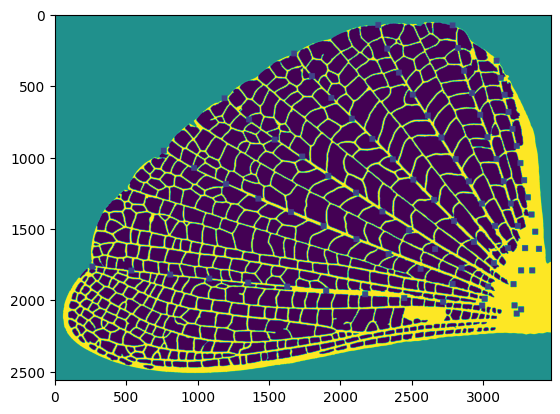

In [63]:
plt.imshow(a.gray)
# plt.plot(a.img_x,a.img_y,'.')
# plt.plot(pt[:,:,0],pt[:,:,1],'*')
plt.imsave(fname='ref_lmk.png', arr=a.gray)

In [35]:
# get first section 
(m,n)=a.gray.shape

In [36]:
mask=np.zeros((m,n))


In [37]:
pt[0,2],pt[0,4]

(array([2714.68127698, 2014.63424624]), array([2169.40419792, 1961.98439947]))

In [69]:
mask=np.loadtxt("whole_wing_mask.txt")

In [70]:
mask[2000,2500]

0.0

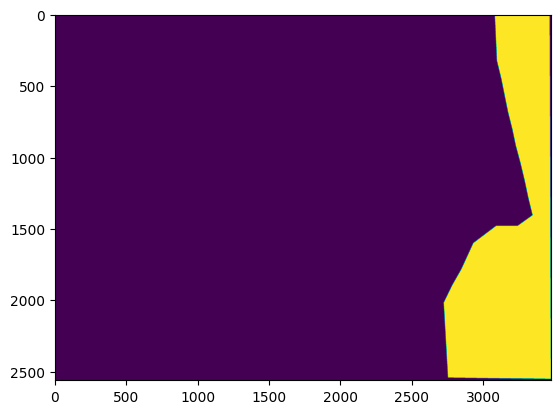

In [71]:
plt.imshow(mask)

In [73]:
a.gray[0,0]

0.5

In [74]:
# generate whole wing mask 
final_mask=np.zeros((m,n))
for i in range(m):
    for j in range(n):
        if a.gray[i,j]==0.5 or mask[i,j]==255:
            final_mask[i,j]=0
        else:
            final_mask[i,j]=1

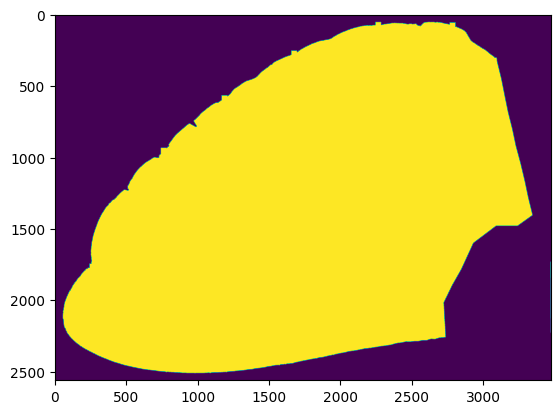

In [75]:
plt.imshow(final_mask)

In [81]:
np.save("whole_wing_mask",final_mask)

In [82]:
mask1=np.loadtxt("mask1.txt")

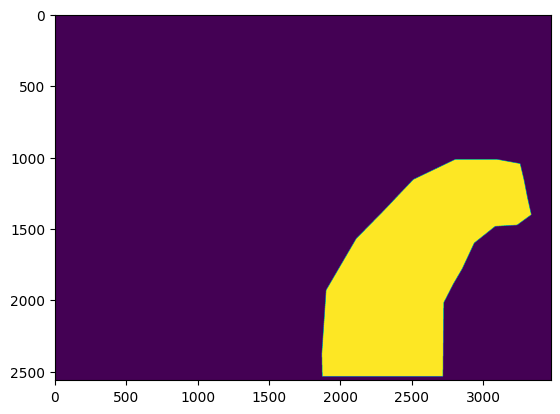

In [83]:
plt.imshow(mask1)

In [89]:
# generate section 1 mask
final_mask1=np.zeros((m,n))
for i in range(m):
    for j in range(n):
        if a.gray[i,j]==0.5 or mask1[i,j]==0 or final_mask[i,j]==0:
            final_mask1[i,j]=0
        else:
            final_mask1[i,j]=1

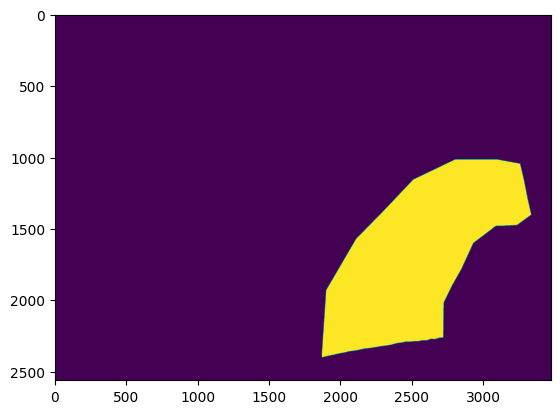

In [90]:
plt.imshow(final_mask1)

In [91]:
np.save("sub_mask1",final_mask1)

In [92]:
mask2=np.loadtxt("mask2.txt")

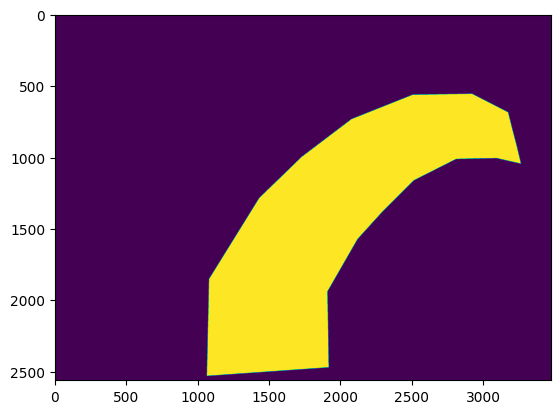

In [95]:
plt.imshow(mask2)

In [96]:
# generate section 2 mask
final_mask2=np.zeros((m,n))
for i in range(m):
    for j in range(n):
        if a.gray[i,j]==0.5 or final_mask1[i,j]==1 or final_mask[i,j]==0 or mask2[i,j]==0:
            final_mask2[i,j]=0
        else:
            final_mask2[i,j]=1

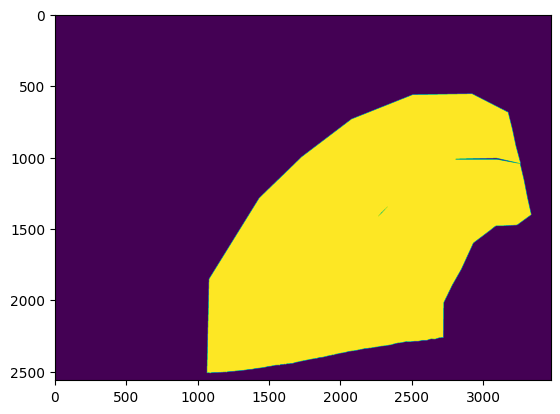

In [100]:
plt.imshow(final_mask2+final_mask1)


In [98]:
np.save("sub_mask2",final_mask2)

In [101]:
mask3=np.loadtxt("mask3.txt")

In [102]:
# generate section 3 mask
final_mask3=np.zeros((m,n))
for i in range(m):
    for j in range(n):
        if a.gray[i,j]==0.5 or final_mask2[i,j]==1 or final_mask[i,j]==0 or mask3[i,j]==0:
            final_mask3[i,j]=0
        else:
            final_mask3[i,j]=1

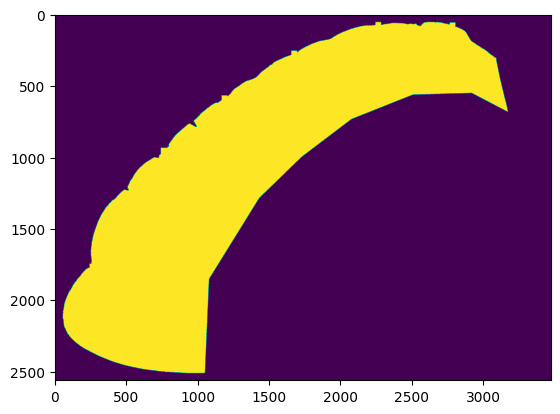

In [106]:
plt.imshow(final_mask3)

In [107]:
np.save("sub_mask3",final_mask3)

In [109]:
circ.shape

(2561, 3475)

In [110]:
final_mask3.shape

(2561, 3475)

In [120]:
circ3=circ*final_mask3
circ3[circ3<0]=0
area3=area*final_mask3
area3[area3<0]=0

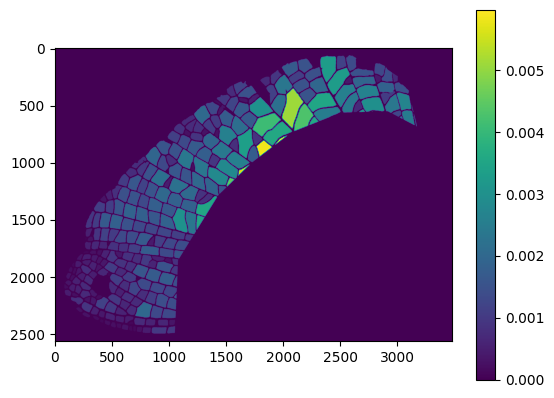

In [121]:
plt.imshow(area3)
plt.colorbar()

In [123]:
np.mean(area3),np.mean(circ3)

(0.00039818464803342016, 0.16609092516503315)

In [124]:
circ2=circ*final_mask2
circ2[circ2<0]=0
area2=area*final_mask2
area2[area2<0]=0

In [125]:
np.mean(area2),np.mean(circ2)

(0.00048384736011943365, 0.11540318941871526)

In [126]:
circ1=circ*final_mask1
circ1[circ1<0]=0
area1=area*final_mask1
area1[area1<0]=0

In [127]:
np.mean(area1),np.mean(circ1)

(0.00019542428223921635, 0.062356407053713835)

In [132]:
norm1=np.count_nonzero(final_mask1)
norm2=np.count_nonzero(final_mask2)
norm3=np.count_nonzero(final_mask3)

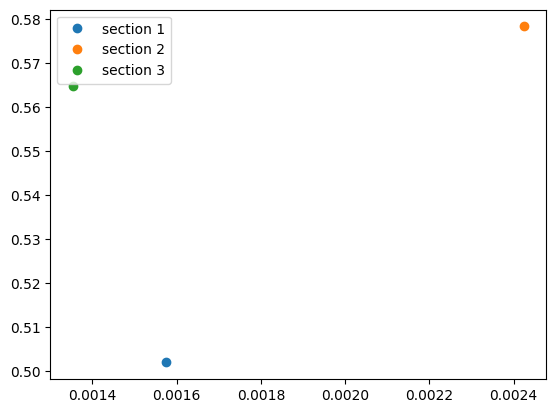

In [133]:
plt.plot(np.sum(area1)/norm1,np.sum(circ1)/norm1,'o',label="section 1")
plt.plot(np.sum(area2)/norm2,np.sum(circ2)/norm2,'o',label="section 2")
plt.plot(np.sum(area3)/norm3,np.sum(circ3)/norm3,'o',label="section 3")
plt.legend()

In [136]:
# generate final masks 
final_masks=[]
for k in range(9):
    print("mask ",k)
    mask_k=np.loadtxt("msk%d.txt"%(k+1))
    tmp=np.zeros((m,n))
    for i in range(m):
        for j in range(n):
            # if a.gray[i,j]==0.5 or final_masks[k-1][i,j]==1 or final_mask[i,j]==0 or mask_k[i,j]==0:
            if a.gray[i,j]==0.5 or final_mask[i,j]==0 or mask_k[i,j]==0:
                tmp[i,j]=0
            else:
                tmp[i,j]=1
    
    final_masks.append(tmp)
        

In [147]:
for k in range(9):
    np.save("final_sub_mask%d"%(k+1),final_masks[k])

In [142]:
# general P-D trace
final_area=np.zeros(9)
final_circ=np.zeros(9)
for k in range(9):
    circ_k=circ*final_masks[k]
    circ_k[circ_k<0]=0
    area_k=area*final_masks[k]
    area_k[area_k<0]=0
    norm_k=np.count_nonzero(final_masks[k])
    
    final_area[k]=np.sum(area_k)/norm_k
    final_circ[k]=np.sum(circ_k)/norm_k

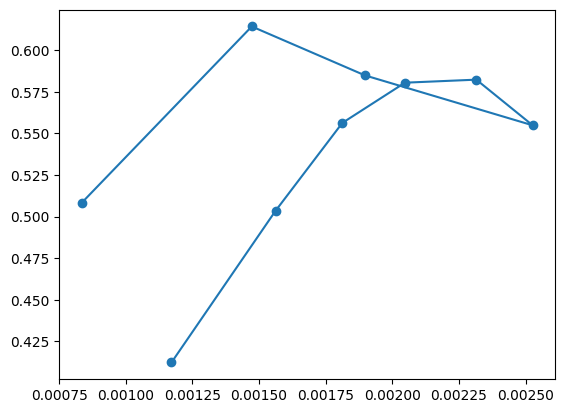

In [143]:
plt.plot(final_area,final_circ,"o-")

Text(0, 0.5, 'cell circularity')

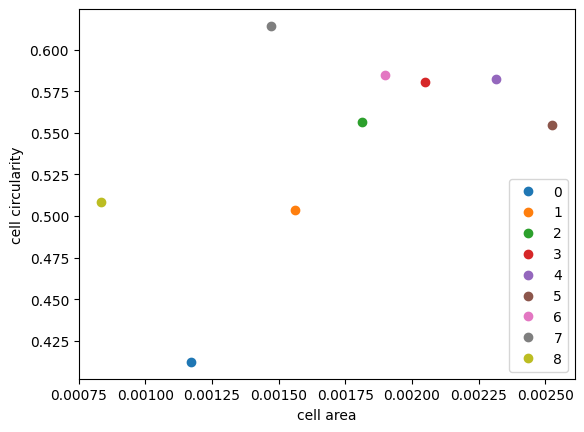

In [145]:
for k in range(9):
    plt.plot(final_area[k],final_circ[k],"o",label=k)

plt.legend()
plt.xlabel("cell area")
plt.ylabel("cell circularity")

In [300]:
name_list=["population_130+FMNH_4598426",
           "population_130+FMNH_4598456",
           "population_130+FMNH_4598491",
           "population_130+FMNH_4598492",
           "population_130+FMNH_4598498",
           "population_130+FMNH_4598501",
           "population_130+FMNH_4598505",
           "population_130+FMNH_4598536"]

all_circ=[]
all_area=[]
for k in range(8):
    circ=np.loadtxt("./wing_stats/"+name_list[k]+"_hw_mapped_cell_circularity.txt")
    area=np.loadtxt("./wing_stats/"+name_list[k]+"_hw_mapped_cell_frac_area.txt")
    
    all_circ.append(circ)
    all_area.append(area)

In [149]:
# general P-D trace for 8 species 
final_area=np.zeros((8,9))
final_circ=np.zeros((8,9))

for n in range(8):
    for k in range(9):
        circ_k=all_circ[n]*final_masks[k]
        circ_k[circ_k<0]=0
        area_k=all_area[n]*final_masks[k]
        area_k[area_k<0]=0
        norm_k=np.count_nonzero(final_masks[k])
        
        final_area[n,k]=np.sum(area_k)/norm_k
        final_circ[n,k]=np.sum(circ_k)/norm_k

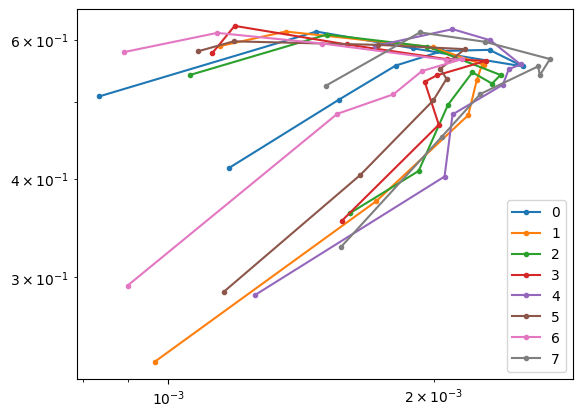

In [158]:
for i in range(8):
    plt.plot(final_area[i,:],final_circ[i,:],'.-',label=i)

plt.xscale('log')
plt.yscale('log')
plt.legend()

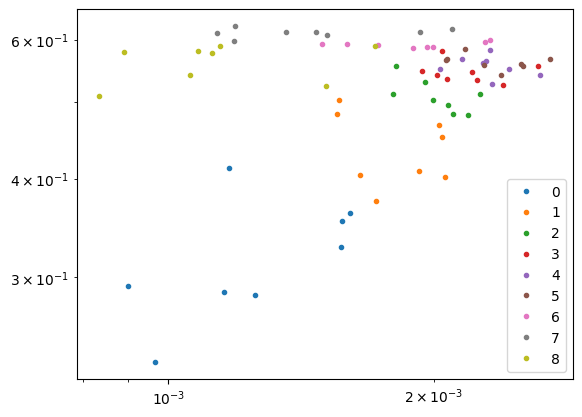

In [159]:
for i in range(9):
    plt.plot(final_area[:,i],final_circ[:,i],'.',label=i)
plt.xscale('log')
plt.yscale('log')    
plt.legend()

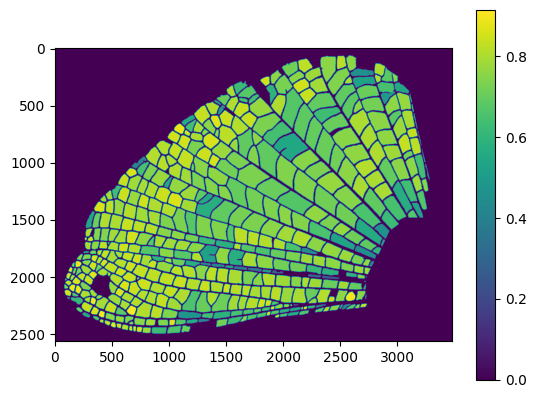

In [166]:
result=all_circ[0]*final_mask
result[result<0]=0
plt.imshow(result)
plt.colorbar()

In [167]:
result2=result[result>0]
result2.shape

(4130745,)

In [168]:
result.shape

(2561, 3475)

In [169]:
2561*3475

8899475

# calculate distribution

In [174]:
result=np.loadtxt("./wing_stats/"+name_list[0]+"_hw_mapped_cell_index.txt")

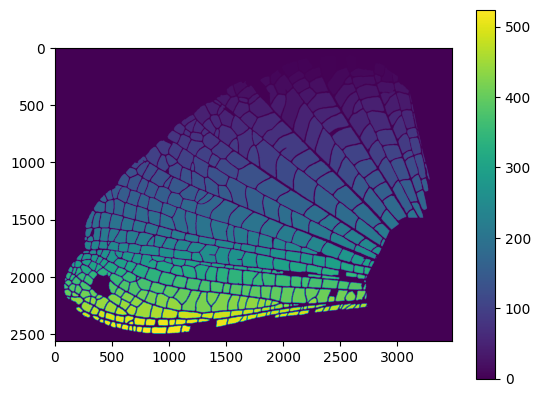

In [182]:
plt.imshow(result*final_mask)
plt.colorbar()

In [179]:
cell_stat=np.loadtxt("./wing_stats/"+name_list[0]+"_hw_cells_stat.txt")

In [189]:
cell_stat[0]

array([1.00000000e+00, 7.77200000e+03, 9.12350000e+03, 8.24115199e-01,
       3.72985293e+02])

In [183]:
mapped=result*final_mask

In [184]:
mapped.shape

(2561, 3475)

In [188]:
unique_mapped=np.unique(mapped)

In [190]:
unique_mapped=unique_mapped[unique_mapped>0]

In [191]:
unique_mapped

array([  1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
        12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,
        23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,
        45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,
        56.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,  66.,  67.,
        68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,  77.,  78.,
        79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,  88.,  90.,
        91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,  99., 100., 101.,
       102., 103., 104., 105., 106., 107., 108., 109., 110., 111., 112.,
       114., 115., 116., 117., 118., 119., 120., 121., 122., 123., 124.,
       125., 126., 127., 128., 129., 130., 131., 132., 133., 134., 135.,
       136., 137., 138., 139., 140., 141., 142., 143., 144., 145., 146.,
       147., 148., 149., 150., 151., 152., 153., 15

In [194]:
whole_circ=np.zeros(len(unique_mapped))
whole_area=np.zeros(len(unique_mapped))
for i,val in enumerate(unique_mapped):
        whole_area[i]=cell_stat[int(val)-1,2]
        whole_circ[i]=cell_stat[int(val)-1,3]


0 1.0
1 2.0
2 3.0
3 4.0
4 5.0
5 6.0
6 7.0
7 8.0
8 9.0
9 10.0
10 11.0
11 12.0
12 13.0
13 14.0
14 15.0
15 16.0
16 17.0
17 18.0
18 19.0
19 20.0
20 21.0
21 22.0
22 23.0
23 24.0
24 25.0
25 26.0
26 27.0
27 28.0
28 29.0
29 30.0
30 31.0
31 32.0
32 33.0
33 34.0
34 35.0
35 36.0
36 37.0
37 38.0
38 39.0
39 40.0
40 41.0
41 42.0
42 43.0
43 44.0
44 45.0
45 46.0
46 47.0
47 48.0
48 49.0
49 50.0
50 51.0
51 52.0
52 53.0
53 54.0
54 55.0
55 56.0
56 58.0
57 59.0
58 60.0
59 61.0
60 62.0
61 63.0
62 64.0
63 65.0
64 66.0
65 67.0
66 68.0
67 69.0
68 70.0
69 71.0
70 72.0
71 73.0
72 74.0
73 75.0
74 76.0
75 77.0
76 78.0
77 79.0
78 80.0
79 81.0
80 82.0
81 83.0
82 84.0
83 85.0
84 86.0
85 87.0
86 88.0
87 90.0
88 91.0
89 92.0
90 93.0
91 94.0
92 95.0
93 96.0
94 97.0
95 98.0
96 99.0
97 100.0
98 101.0
99 102.0
100 103.0
101 104.0
102 105.0
103 106.0
104 107.0
105 108.0
106 109.0
107 110.0
108 111.0
109 112.0
110 114.0
111 115.0
112 116.0
113 117.0
114 118.0
115 119.0
116 120.0
117 121.0
118 122.0
119 123.0
120 124.0
121 12

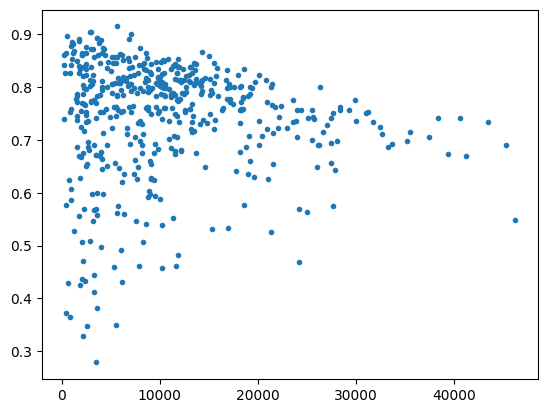

In [195]:
plt.plot(whole_area,whole_circ,".")

In [196]:
# calculate distribution for all wings

all_whole_area=[]
all_whole_circ=[]

for n in range(8):
    result=np.loadtxt("./wing_stats/"+name_list[n]+"_hw_mapped_cell_index.txt")
    cell_stat=np.loadtxt("./wing_stats/"+name_list[n]+"_hw_cells_stat.txt")
    mapped=result*final_mask #apply the whole wing mask
    unique_mapped=np.unique(mapped) #get the unique cell index 
    unique_mapped=unique_mapped[unique_mapped>0]
    whole_circ=np.zeros(len(unique_mapped))
    whole_area=np.zeros(len(unique_mapped))
    for i,val in enumerate(unique_mapped):
        whole_area[i]=cell_stat[int(val)-1,2]
        whole_circ[i]=cell_stat[int(val)-1,3]
    
    all_whole_area.append(whole_area)
    all_whole_circ.append(whole_circ)
    
            

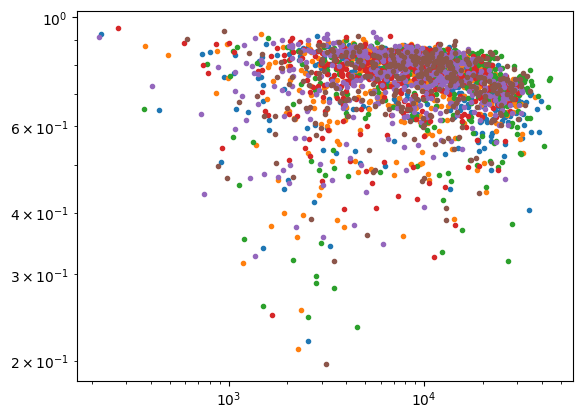

In [203]:
# for n in range():
for n in range(2,8):
    plt.plot(all_whole_area[n],all_whole_circ[n],".")

plt.xscale('log')
plt.yscale('log')

In [204]:
# calculate distribution for all wings across different sections 

all_whole_area_section=[]
all_whole_circ_section=[]

for n in range(8):
    result=np.loadtxt("./wing_stats/"+name_list[n]+"_hw_mapped_cell_index.txt")
    cell_stat=np.loadtxt("./wing_stats/"+name_list[n]+"_hw_cells_stat.txt")
    for k in range(9):
        mapped=result*final_masks[k] #apply the whole wing mask
        unique_mapped=np.unique(mapped) #get the unique cell index 
        unique_mapped=unique_mapped[unique_mapped>0]
        circ_k=np.zeros(len(unique_mapped))
        area_k=np.zeros(len(unique_mapped))
        for i,val in enumerate(unique_mapped):
            area_k[i]=cell_stat[int(val)-1,2]
            circ_k[i]=cell_stat[int(val)-1,3]
        
        all_whole_area_section.append(area_k)
        all_whole_circ_section.append(circ_k)

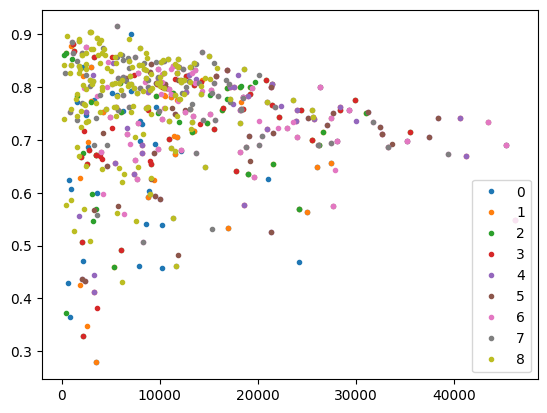

In [219]:
for i in range(9):
    plt.plot(all_whole_area_section[i],all_whole_circ_section[i],'.',label=i)
plt.legend()

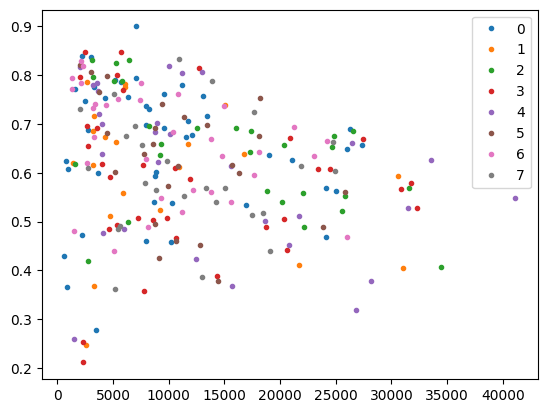

In [231]:
idx=0
for i in range(8):
    plt.plot(all_whole_area_section[idx+i*9],all_whole_circ_section[idx+i*9],'.',label=i)
plt.legend()

In [247]:
# find the max and min 
max_area=0
min_area=10000
max_circ=0
min_circ=1
for i in range(72): 
    tmp=max(all_whole_area_section[i])
    if tmp>max_area:
        max_area=tmp
    tmp=min(all_whole_area_section[i])
    if tmp<min_area:
        min_area=tmp
    
    tmp=max(all_whole_circ_section[i])
    if tmp>max_circ:
        max_circ=tmp
    tmp=min(all_whole_circ_section[i])
    if tmp<min_circ:
        min_circ=tmp
        

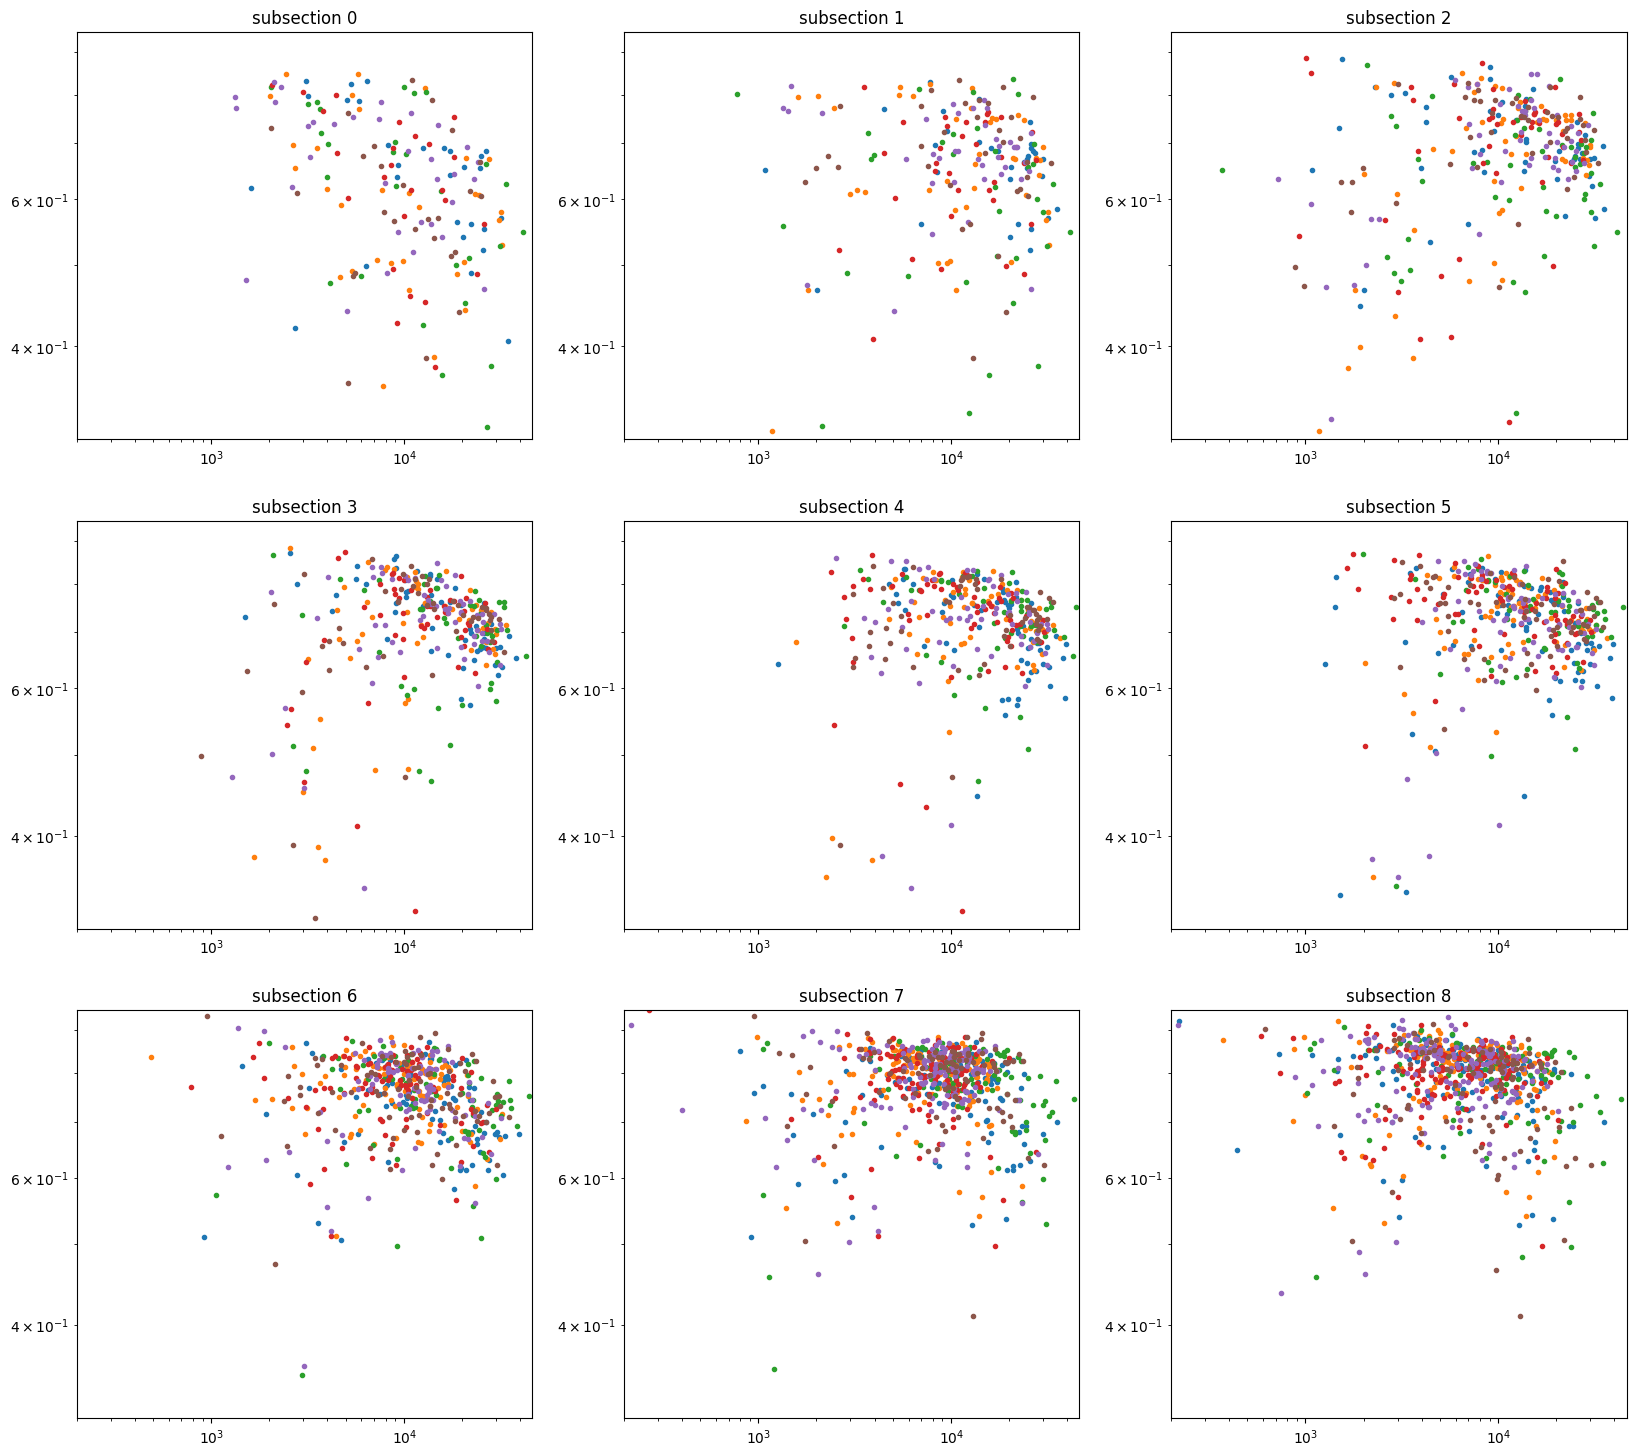

In [252]:
fig,ax=plt.subplots(3,3,figsize=(20,18))
for j in range(9):
    for i in range(2,8):
    
        ax[j//3,j%3].plot(all_whole_area_section[j+i*9],all_whole_circ_section[j+i*9],'.')
        ax[j//3,j%3].set_title("subsection %d"%j)
        ax[j//3,j%3].set_xscale('log')
        ax[j//3,j%3].set_yscale('log')
        ax[j//3,j%3].set_xlim(200,max_area)
        ax[j//3,j%3].set_ylim(min_circ+0.2,max_circ)
        
        
        
        
    

In [245]:
# find the max and min 
max_area=0
min_area=10000
max_circ=0
min_circ=1
for i in range(72): 
    tmp=max(all_whole_area_section[i])
    if tmp>max_area:
        max_area=tmp
    tmp=min(all_whole_area_section[i])
    if tmp<min_area:
        min_area=tmp
    
    tmp=max(all_whole_circ_section[i])
    if tmp>max_circ:
        max_circ=tmp
    tmp=min(all_whole_circ_section[i])
    if tmp<min_circ:
        min_circ=tmp
        
    

In [246]:
print(max_area,min_area,max_circ,min_circ)

46187.5 3.0 0.9520531720676364 0.1096275246472963


## Generate horizontal masks 

In [254]:
whole_wing_mask=np.load('./whole_wing_mask.npy')

In [260]:
(m,n)=gray.shape

In [262]:
# generate section 1 mask
hmask1=np.loadtxt("./hmask1.txt")

final_hmask1=np.zeros((m,n))
for i in range(m):
    for j in range(n):
        if a.gray[i,j]==0.5 or hmask1[i,j]==0 or whole_wing_mask[i,j]==0:
            final_hmask1[i,j]=0
        else:
            final_hmask1[i,j]=1

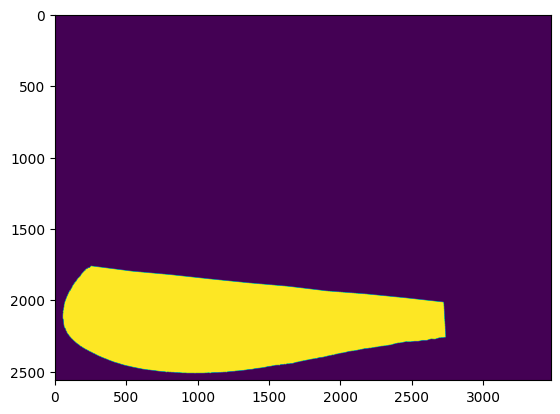

In [264]:
plt.imshow(final_hmask1)

In [265]:
np.save("final_hmask1",final_hmask1)

In [266]:
# generate section 1 mask
hmask2=np.loadtxt("./hmask2.txt")

final_hmask2=np.zeros((m,n))
for i in range(m):
    for j in range(n):
        if a.gray[i,j]==0.5 or hmask2[i,j]==0 or final_hmask1[i,j]==1 or whole_wing_mask[i,j]==0:
            final_hmask2[i,j]=0
        else:
            final_hmask2[i,j]=1

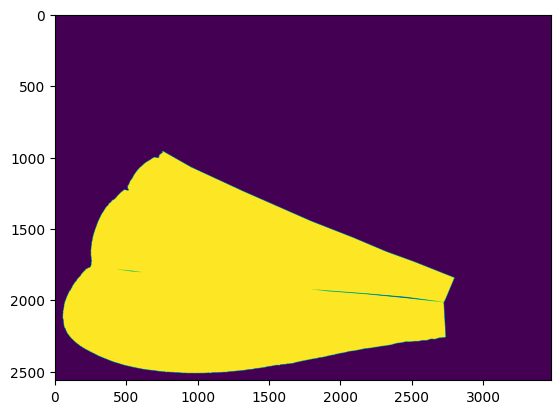

In [268]:
plt.imshow(final_hmask2+final_hmask1)

In [270]:
# generate final masks 
final_hmasks=[]
for k in range(7):
    print("mask ",k)
    mask_k=np.loadtxt("hmask%d.txt"%(k+1))
    tmp=np.zeros((m,n))
    for i in range(m):
        for j in range(n):
            # if a.gray[i,j]==0.5 or final_masks[k-1][i,j]==1 or final_mask[i,j]==0 or mask_k[i,j]==0:
            if a.gray[i,j]==0.5 or whole_wing_mask[i,j]==0 or mask_k[i,j]==0:
                tmp[i,j]=0
            else:
                tmp[i,j]=1
    
    final_hmasks.append(tmp)
        

mask  0
mask  1
mask  2
mask  3
mask  4
mask  5
mask  6


In [271]:
for k in range(7):
    np.save("final_hori_mask%d"%(k+1),final_hmasks[k])

IndexError: list index out of range

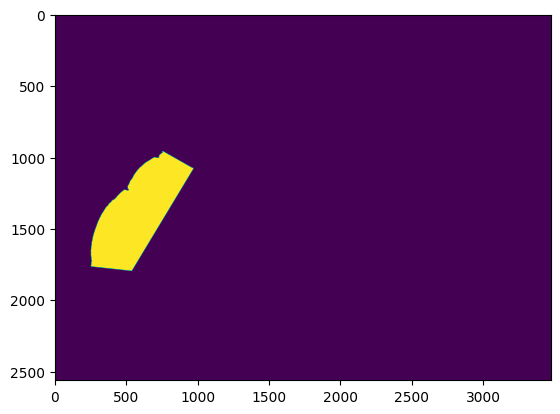

In [284]:
plt.imshow(final_hmasks[1]*final_masks[8])

In [301]:
# general P-D trace for 8 species and 7 horizontal sections 
final_area=np.zeros((8,9,7))
final_circ=np.zeros((8,9,7))

# 8 specemens
for n in range(8):
    # 9 vertical sections 
    for k in range(9):
        # 7 horizontal sections 
        for j in range(7):
            mask_k=final_masks[k]*final_hmasks[j]
            circ_k=all_circ[n]*mask_k
            circ_k[circ_k<0]=0
            area_k=all_area[n]*mask_k
            area_k[area_k<0]=0
            norm_k=np.count_nonzero(mask_k)
            
            final_area[n,k,j]=np.sum(area_k)/norm_k
            final_circ[n,k,j]=np.sum(circ_k)/norm_k

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


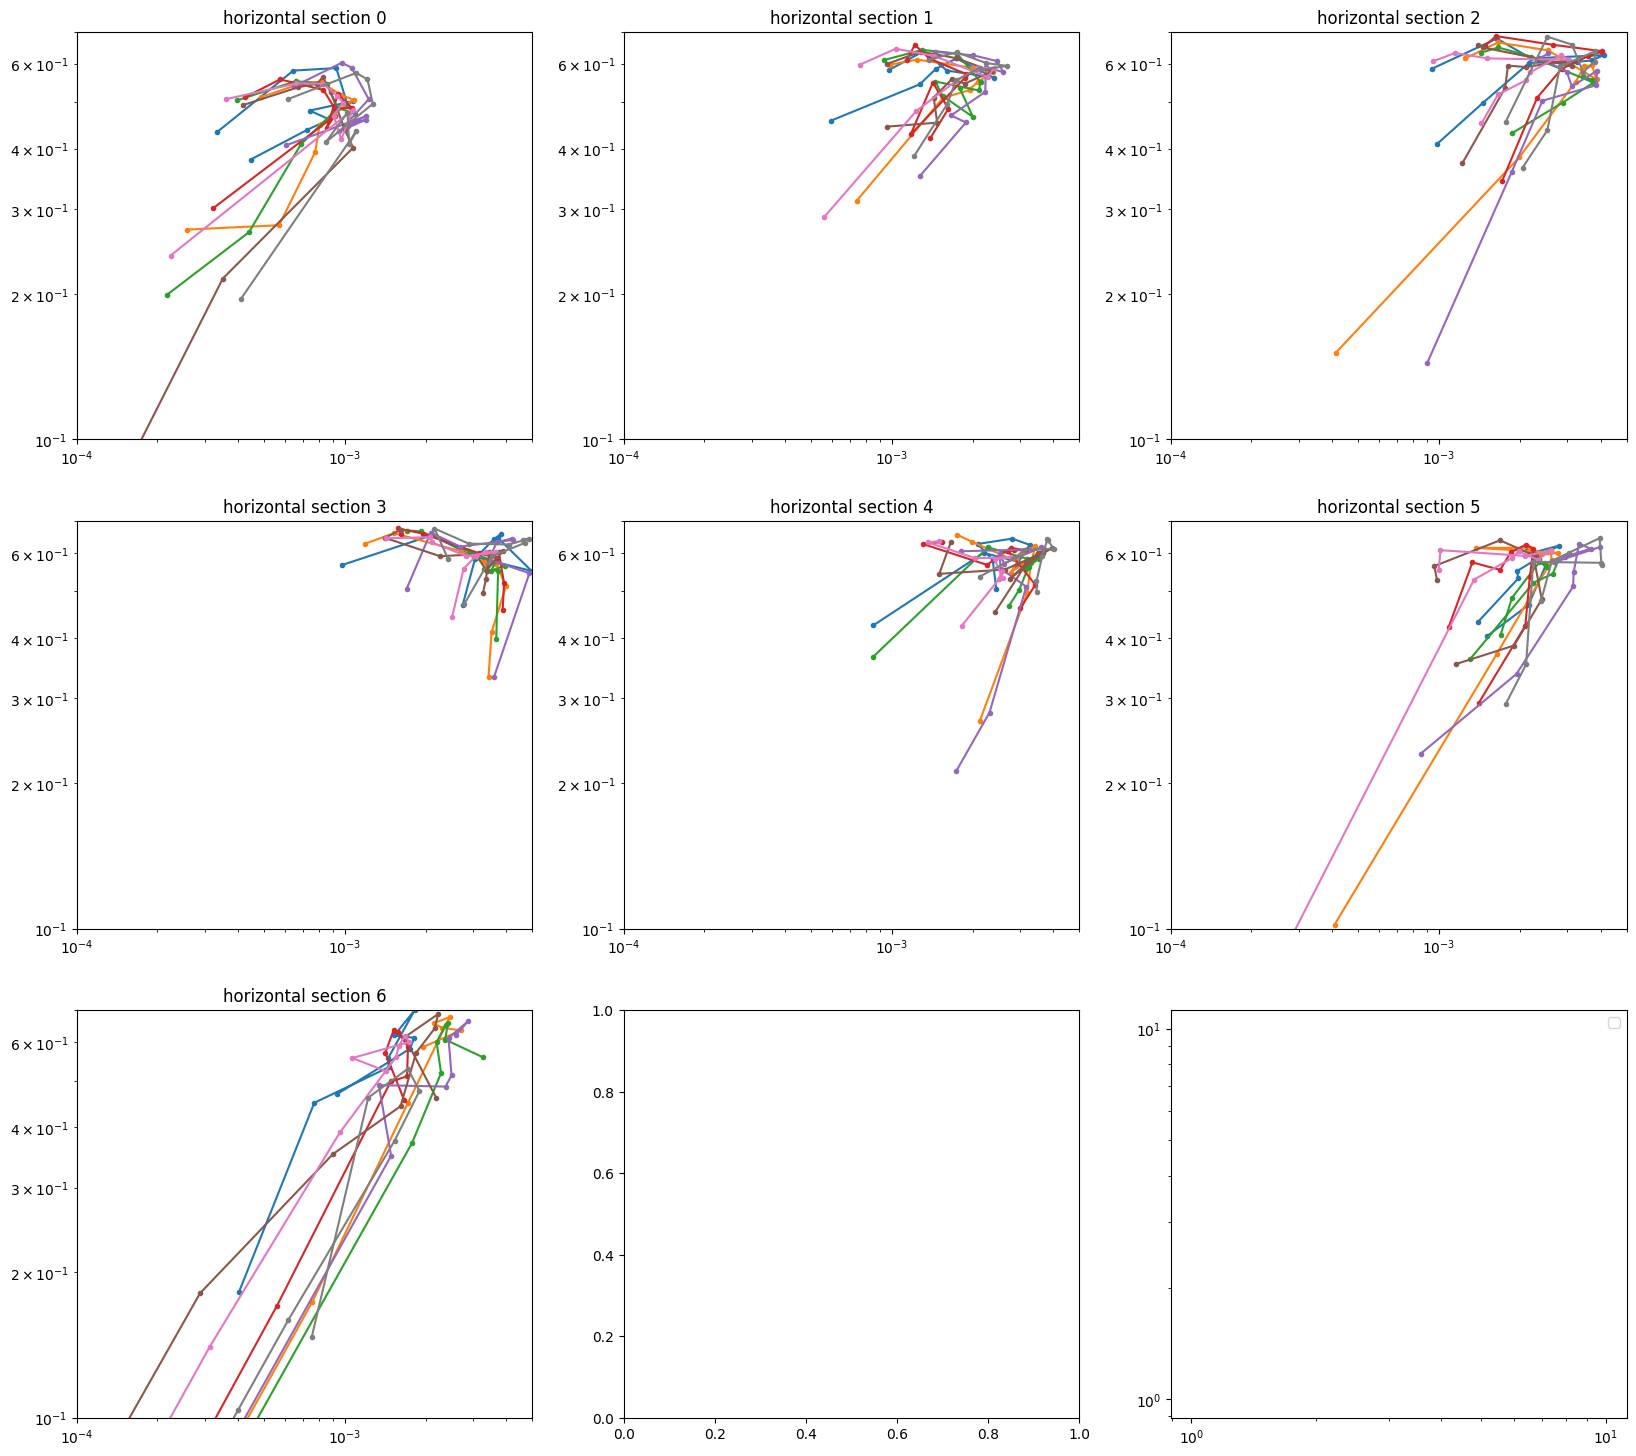

In [312]:
# look at 7 horizontal sections 
fig,ax=plt.subplots(3,3,figsize=(20,18))

for j in range(7):
    for i in range(8):
        ax[j//3,j%3].plot(final_area[i,:,j],final_circ[i,:,j],'.-',label="speciment %d"%i)
        ax[j//3,j%3].set_title("horizontal section %d"%j)
        ax[j//3,j%3].set_xscale("log")
        ax[j//3,j%3].set_yscale("log")
        ax[j//3,j%3].set_xlim(0.0001,0.005)
        ax[j//3,j%3].set_ylim(0.1,0.7)

plt.xscale('log')
plt.yscale('log')
plt.legend()

## P-D trace for three populations

In [325]:
def read_circ_area(name_list):
    all_circ=[]
    all_area=[]
    for k in range(len(name_list)):
        circ=np.loadtxt("./wing_stats/"+name_list[k]+"_hw_mapped_cell_circularity.txt")
        area=np.loadtxt("./wing_stats/"+name_list[k]+"_hw_mapped_cell_area.txt")
        
        all_circ.append(circ)
        all_area.append(area)

    return all_circ,all_area
    

In [319]:
def pd_trace(all_circ,all_area,N):
    # general P-D trace for N species and 7 horizontal sections 
    final_area=np.zeros((N,9,7))
    final_circ=np.zeros((N,9,7))

    # 8 specemens
    for n in range(N):
        # 9 vertical sections 
        for k in range(9):
            # 7 horizontal sections 
            for j in range(7):
                mask_k=final_masks[k]*final_hmasks[j]
                circ_k=all_circ[n]*mask_k
                circ_k[circ_k<0]=0
                area_k=all_area[n]*mask_k
                area_k[area_k<0]=0
                norm_k=np.count_nonzero(mask_k)
                
                final_area[n,k,j]=np.sum(area_k)/norm_k
                final_circ[n,k,j]=np.sum(circ_k)/norm_k
    
    return final_circ,final_area
    

In [326]:
name_list_130=["population_130+FMNH_4598607",
               "population_130+FMNH_4598589",
               "population_130+FMNH_4598563",
               "population_130+FMNH_4598536",
               "population_130+FMNH_4598505",
               "population_130+FMNH_4598501",
               "population_130+FMNH_4598498",
               "population_130+FMNH_4598492",
               "population_130+FMNH_4598491",
               "population_130+FMNH_4598456",
               "population_130+FMNH_4598426"]

all_circ_130,all_area_130=read_circ_area(name_list_130)

In [327]:
final_circ_130,final_area_130=pd_trace(all_circ_130,all_area_130,len(name_list_130))

In [329]:
# population 152
name_list_152=["population_152+FMNH_4601873",
               "population_152+FMNH_4601886",
               "population_152+FMNH_4601888",
               "population_152+FMNH_4601955",
               "population_152+FMNH_4601996",
               "population_152+FMNH_4602097",
               "population_152+FMNH_4602132",
               "population_152+FMNH_4602176",
               "population_152+FMNH_4602177",
               "population_152+FMNH_4602179",
               "population_152+FMNH_4602000"]

all_circ_152,all_area_152=read_circ_area(name_list_152)

In [330]:
final_circ_152,final_area_152=pd_trace(all_circ_152,all_area_152,len(name_list_152))

In [332]:
# population 60
name_list_60=["population_60+FMNH_4602457",
              "population_60+FMNH_4602438",
              "population_60+FMNH_4602389",
              "population_60+FMNH_4602368",
              "population_60+FMNH_4602345",
              "population_60+FMNH_4602308",
              "population_60+FMNH_4602304",
              "population_60+FMNH_4602260",
              "population_60+FMNH_4602200"]

all_circ_60,all_area_60=read_circ_area(name_list_60)

In [333]:
final_circ_60,final_area_60=pd_trace(all_circ_60,all_area_60,len(name_list_60))

In [335]:
np.mean(final_area_60[0,:,:],axis=1)

array([10026.30862037, 12107.22001115, 14707.90425394, 14857.92930524,
       16157.15386198, 15058.6066443 , 11790.76493989,  9976.87284941,
        7926.6041994 ])

Text(0, 0.5, 'cell circularity')

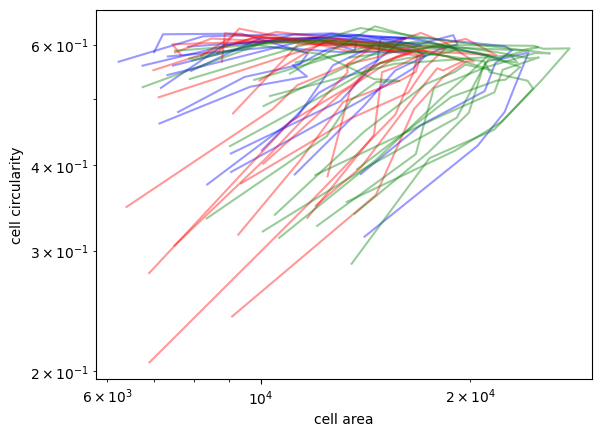

In [350]:
# plot all PD trace
fig,ax=plt.subplots()
for i in range(len(name_list_60)):
    ax.plot(np.mean(final_area_60[i,:,:],axis=1),np.mean(final_circ_60[i,:,:],axis=1),'-',color='b',alpha=0.4)
    
for i in range(len(name_list_130)):
    ax.plot(np.mean(final_area_130[i,:,:],axis=1),np.mean(final_circ_130[i,:,:],axis=1),'-',color='r',alpha=0.4)

for i in range(len(name_list_152)):
    ax.plot(np.mean(final_area_152[i,:,:],axis=1),np.mean(final_circ_152[i,:,:],axis=1),'-',color='g',alpha=0.4)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("cell area")
ax.set_ylabel("cell circularity")   

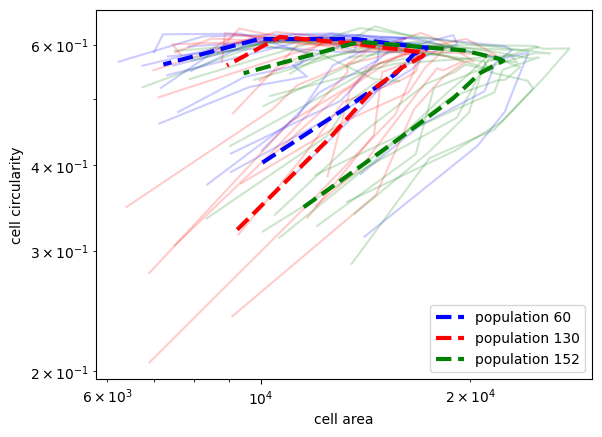

In [417]:
# plot all PD trace
fig,ax=plt.subplots()
for i in range(len(name_list_60)):
    ax.plot(np.mean(final_area_60[i,:,:],axis=1),np.mean(final_circ_60[i,:,:],axis=1),'-',color='b',alpha=0.2)
    
for i in range(len(name_list_130)):
    ax.plot(np.mean(final_area_130[i,:,:],axis=1),np.mean(final_circ_130[i,:,:],axis=1),'-',color='r',alpha=0.2)

for i in range(len(name_list_152)):
    ax.plot(np.mean(final_area_152[i,:,:],axis=1),np.mean(final_circ_152[i,:,:],axis=1),'-',color='g',alpha=0.2)

ax.plot(np.mean(np.mean(final_area_60[:,:,:],axis=2),axis=0),
        np.mean(np.mean(final_circ_60[:,:,:],axis=2),axis=0),'--',color='b',lw=3,label="population 60")
ax.plot(np.mean(np.mean(final_area_130[:,:,:],axis=2),axis=0),
        np.mean(np.mean(final_circ_130[:,:,:],axis=2),axis=0),'--',color='r',lw=3,label="population 130")
ax.plot(np.mean(np.mean(final_area_152[:,:,:],axis=2),axis=0),
        np.mean(np.mean(final_circ_152[:,:,:],axis=2),axis=0),'--',color='g',lw=3,label="population 152")


ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("cell area")
ax.set_ylabel("cell circularity")   
ax.legend()
plt.savefig("pd_trace_whole",dpi=300)

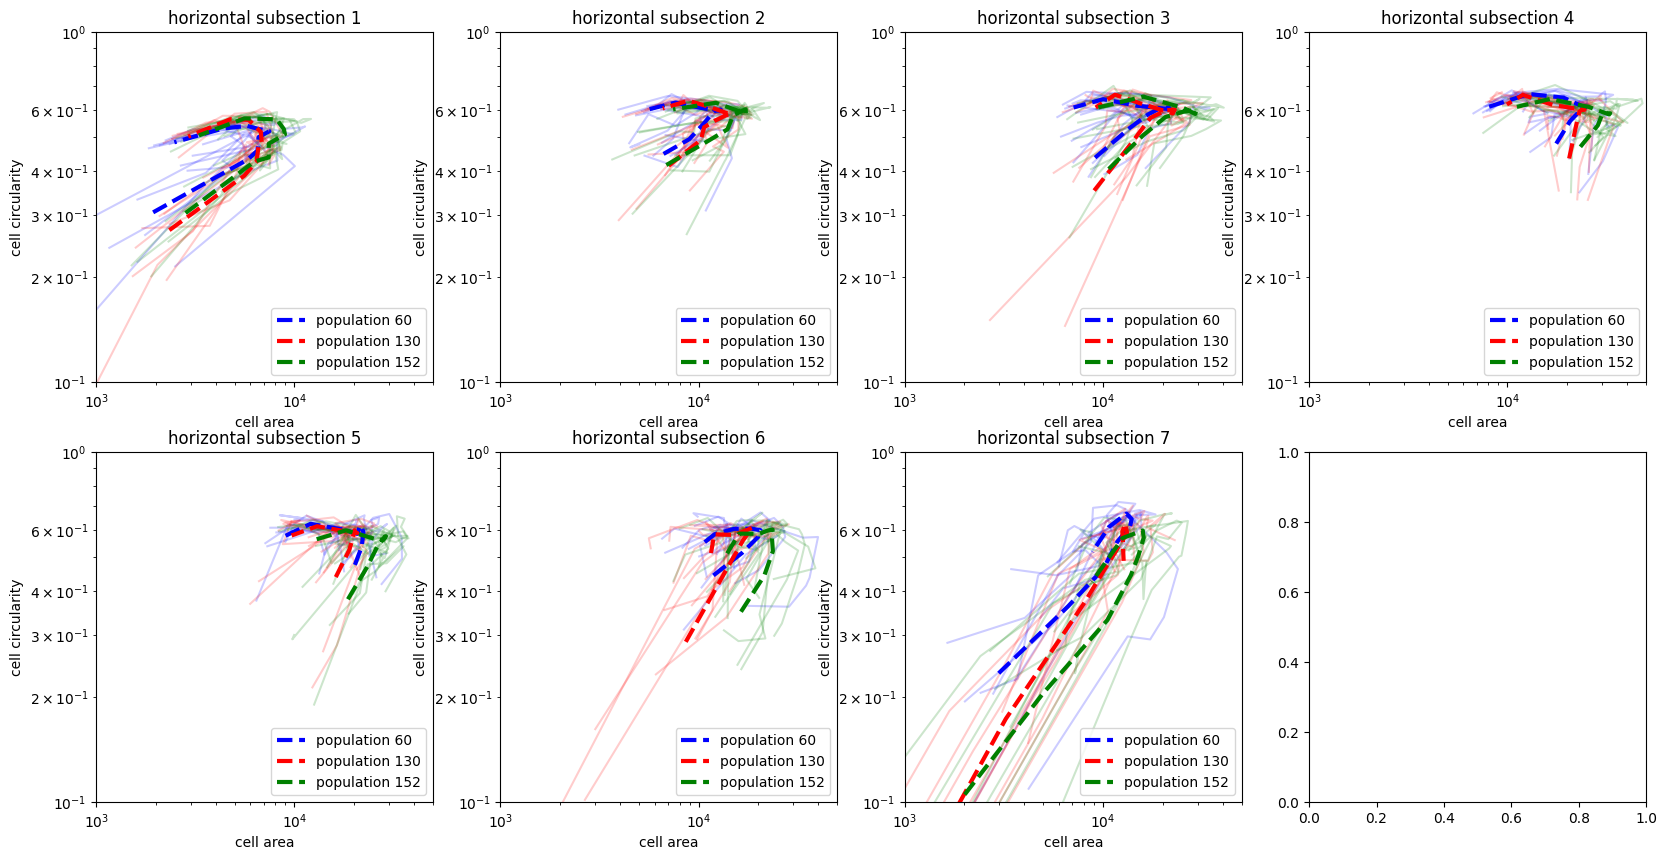

In [437]:
# plot all PD trace
fig,ax=plt.subplots(2,4,figsize=(20,10))

for j in range(7):
    for i in range(len(name_list_60)):
        ax[j//4,j%4].plot(final_area_60[i,:,j],final_circ_60[i,:,j],'-',color='b',alpha=0.2)
    for i in range(len(name_list_130)):
        ax[j//4,j%4].plot(final_area_130[i,:,j],final_circ_130[i,:,j],'-',color='r',alpha=0.2)
    for i in range(len(name_list_152)):
        ax[j//4,j%4].plot(final_area_152[i,:,j],final_circ_152[i,:,j],'-',color='g',alpha=0.2)
    
    ax[j//4,j%4].plot(np.mean(final_area_60[:,:,j],axis=0),
                      np.mean(final_circ_60[:,:,j],axis=0),'--',color='b',lw=3,label="population 60")
    ax[j//4,j%4].plot(np.mean(final_area_130[:,:,j],axis=0),
                      np.mean(final_circ_130[:,:,j],axis=0),'--',color='r',lw=3,label="population 130")
    ax[j//4,j%4].plot(np.mean(final_area_152[:,:,j],axis=0),
                      np.mean(final_circ_152[:,:,j],axis=0),'--',color='g',lw=3,label="population 152")
    
    ax[j//4,j%4].set_title("horizontal subsection %d"%(j+1))
    ax[j//4,j%4].set_xscale("log")
    ax[j//4,j%4].set_yscale("log")
    ax[j//4,j%4].set_xlabel("cell area")
    ax[j//4,j%4].set_ylabel("cell circularity")   
    ax[j//4,j%4].set_xlim(1000,50000)
    ax[j//4,j%4].set_ylim(0.1,1)
    ax[j//4,j%4].legend(loc='lower right')

plt.savefig("pd_trace_sction",dpi=300)

In [364]:
7%4

3

## All distribution

In [379]:
# calculate distribution for all wings
def calc_distribution(name_list):

    all_whole_area=[]
    all_whole_circ=[]

    for n in range(len(name_list)):
        result=np.loadtxt("./wing_stats/"+name_list[n]+"_hw_mapped_cell_index.txt")
        cell_stat=np.loadtxt("./wing_stats/"+name_list[n]+"_hw_cells_stat.txt")
        mapped=result*final_mask #apply the whole wing mask
        unique_mapped=np.unique(mapped) #get the unique cell index 
        unique_mapped=unique_mapped[unique_mapped>0]
        whole_circ=np.zeros(len(unique_mapped))
        whole_area=np.zeros(len(unique_mapped))
        for i,val in enumerate(unique_mapped):
            whole_area[i]=cell_stat[int(val)-1,2]
            whole_circ[i]=cell_stat[int(val)-1,3]
        
        all_whole_area.append(whole_area)
        all_whole_circ.append(whole_circ)
    
    return all_whole_circ,all_whole_area

In [414]:
# calculate distribution for all wings
def calc_sub_distribution(name_list):

    all_whole_area=[]
    all_whole_circ=[]

    for n in range(len(name_list)):
        result=np.loadtxt("./wing_stats/"+name_list[n]+"_hw_mapped_cell_index.txt")
        cell_stat=np.loadtxt("./wing_stats/"+name_list[n]+"_hw_cells_stat.txt")
        # 9 vertical sections 
        for k in range(9):
            # 7 horizontal sections 
            for j in range(7):
                mask_k=final_masks[k]*final_hmasks[j]
                
                mapped=result*mask_k #apply the whole wing mask
                unique_mapped=np.unique(mapped) #get the unique cell index 
                unique_mapped=unique_mapped[unique_mapped>0]
                whole_circ=np.zeros(len(unique_mapped))
                whole_area=np.zeros(len(unique_mapped))
                for i,val in enumerate(unique_mapped):
                    whole_area[i]=cell_stat[int(val)-1,2]
                    whole_circ[i]=cell_stat[int(val)-1,3]
                
                all_whole_area.append(whole_area)
                all_whole_circ.append(whole_circ)
    
    return all_whole_circ,all_whole_area

In [380]:
# calculate stats for whole wing
all_whole_circ_60,all_whole_area_60=calc_distribution(name_list_60)
all_whole_circ_130,all_whole_area_130=calc_distribution(name_list_130)
all_whole_circ_152,all_whole_area_152=calc_distribution(name_list_152)

In [425]:
# calculate stats for subsections 
all_sub_circ_60,all_sub_area_60=calc_sub_distribution(name_list_60)
all_sub_circ_130,all_sub_area_130=calc_sub_distribution(name_list_130)
all_sub_circ_152,all_sub_area_152=calc_sub_distribution(name_list_152)

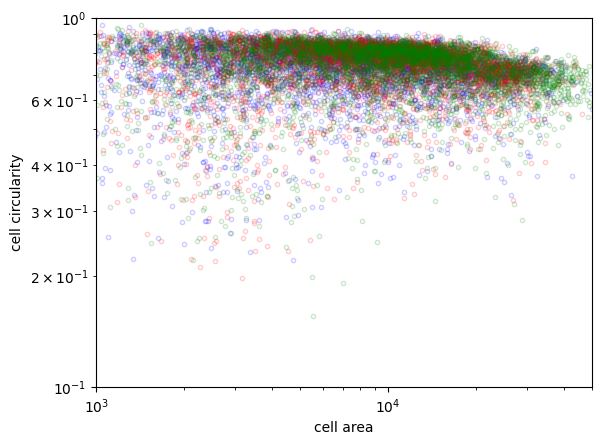

In [424]:
fig,ax=plt.subplots()

for i in range(len(name_list_60)):
    ax.plot(all_whole_area_60[i],all_whole_circ_60[i],'.',color='b',alpha=0.2,mfc='none')

for i in range(len(name_list_130)):
    ax.plot(all_whole_area_130[i],all_whole_circ_130[i],'.',color='r',alpha=0.2,mfc='none')

for i in range(len(name_list_152)):
    ax.plot(all_whole_area_152[i],all_whole_circ_152[i],'.',color='g',alpha=0.2,mfc='none')
    
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1000,50000)
ax.set_ylim(0.1,1)
ax.set_xlabel("cell area")
ax.set_ylabel("cell circularity") 
plt.savefig("area_circ_distribution_whole",dpi=300)

In [409]:
all_sub_area_60[63].shape

(441,)

In [410]:
len(all_sub_area_60)

567

In [411]:
567/63

9.0

In [396]:
len(name_list_60)

9

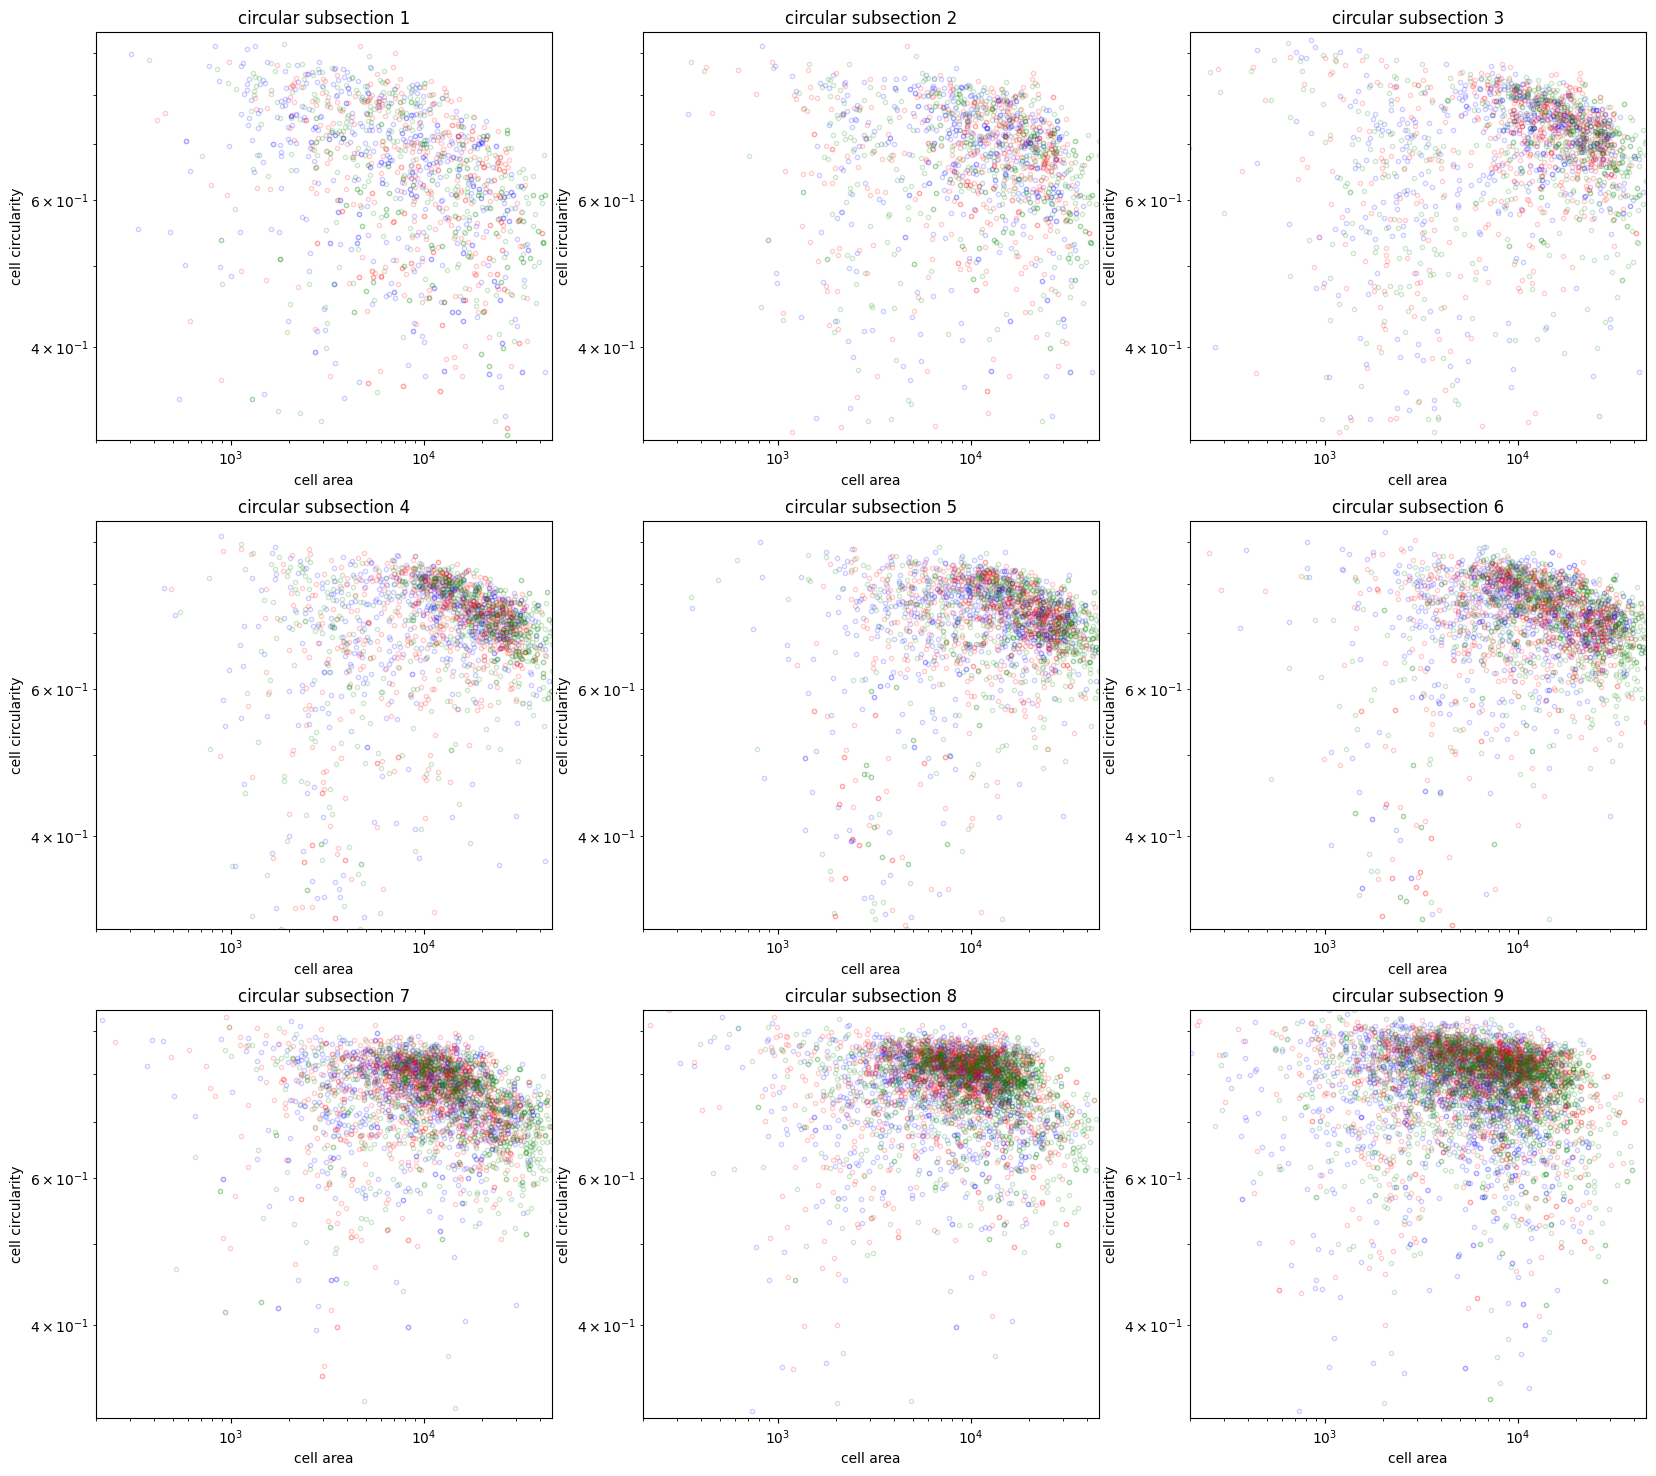

In [436]:
# 9 vertical sections 
fig,ax=plt.subplots(3,3,figsize=(20,18))

for n in range(len(name_list_60)):
    for j in range(9):
        for i in range(7):
            ax[j//3,j%3].plot(all_sub_area_60[i+7*(j+n*9)],all_sub_circ_60[i+7*(j+n*9)],'.',color='b',alpha=0.2,mfc='none')
            
for n in range(len(name_list_130)):
    for j in range(9):
        for i in range(7):
            ax[j//3,j%3].plot(all_sub_area_130[i+7*(j+n*9)],all_sub_circ_130[i+7*(j+n*9)],'.',color='r',alpha=0.2,mfc='none')
            
for n in range(len(name_list_152)):
    for j in range(9):
        for i in range(7):
            ax[j//3,j%3].plot(all_sub_area_152[i+7*(j+n*9)],all_sub_circ_152[i+7*(j+n*9)],'.',color='g',alpha=0.2,mfc='none')
            
            
for j in range(9):
    ax[j//3,j%3].set_xlabel("cell area")
    ax[j//3,j%3].set_ylabel("cell circularity")  
    ax[j//3,j%3].set_title("circular subsection %d"%(j+1))
    ax[j//3,j%3].set_xscale('log')
    ax[j//3,j%3].set_yscale('log')
    ax[j//3,j%3].set_xlim(200,max_area)
    ax[j//3,j%3].set_ylim(min_circ+0.2,max_circ)

plt.savefig("area_cir_distribution_circular_subsection",dpi=300)

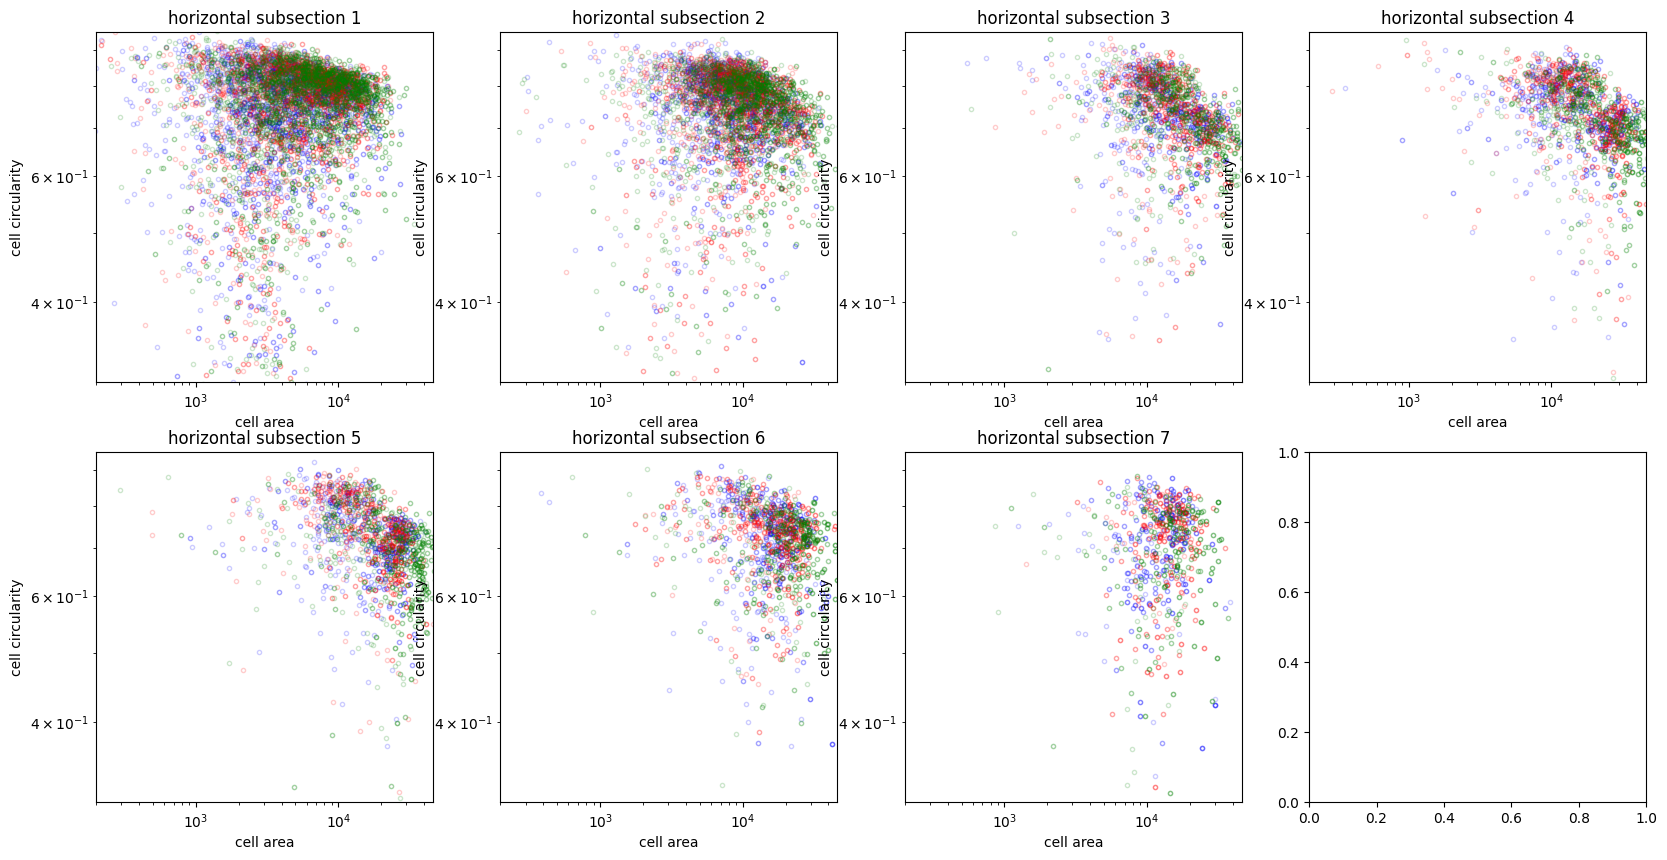

In [435]:
# 7 horizontal sections 
# 9 vertical sections 
fig,ax=plt.subplots(2,4,figsize=(20,10))

for n in range(len(name_list_60)):
    for j in range(9):
        for i in range(7):
            ax[i//4,i%4].plot(all_sub_area_60[i+7*(j+n*9)],all_sub_circ_60[i+7*(j+n*9)],'.',color='b',alpha=0.2,mfc='none')
            
for n in range(len(name_list_130)):
    for j in range(9):
        for i in range(7):
            ax[i//4,i%4].plot(all_sub_area_130[i+7*(j+n*9)],all_sub_circ_130[i+7*(j+n*9)],'.',color='r',alpha=0.2,mfc='none')
            
for n in range(len(name_list_152)):
    for j in range(9):
        for i in range(7):
            ax[i//4,i%4].plot(all_sub_area_152[i+7*(j+n*9)],all_sub_circ_152[i+7*(j+n*9)],'.',color='g',alpha=0.2,mfc='none')
            
            
for i in range(7):
    ax[i//4,i%4].set_xlabel("cell area")
    ax[i//4,i%4].set_ylabel("cell circularity")  
    ax[i//4,i%4].set_title("horizontal subsection %d"%(i+1))
    ax[i//4,i%4].set_xscale('log')
    ax[i//4,i%4].set_yscale('log')
    ax[i//4,i%4].set_xlim(200,max_area)
    ax[i//4,i%4].set_ylim(min_circ+0.2,max_circ)

plt.savefig("area_cir_distribution_horizontal_subsection",dpi=300)